In [51]:
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing.pool import Pool
from albatross import Albatross
from optimiser import Optimiser

In [52]:
bird = Albatross()

def single_optimisation(theta: float, V_ref: float, N: int):
    optimiser = Optimiser(bird=bird, theta=theta, N=N, V_ref=V_ref)
    optimiser.optimise()
    return optimiser 

def serial_sweep(n_points: int, V_refs: list, N: int):
    thetas = np.linspace(0.0, 2*np.pi, n_points, endpoint=False)
    results = []
    for V in V_refs:
        result = {"V_ref": V,
               "solutions": [],
               "thetas": thetas}
        for t in thetas: 
                print("theta = ", t)
                result["solutions"].append(single_optimisation(theta=t, V_ref=V, N=N))
        results.append(result)
    return results

Vs = [13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]
N_STEPS = 100
results = serial_sweep(1, Vs, N=N_STEPS)
N = results[0]['solutions'][0].N

t_norm = np.linspace(0, 1, N)  # t / t_cycle

theta =  0.0
theta =  0.0
theta =  0.0
theta =  0.0
theta =  0.0
theta =  0.0
theta =  0.0
theta =  0.0


In [53]:
import matplotlib as mpl

# --- θ colormap (cyclic: twilight) ---
_cmap = mpl.colormaps['twilight']
_thetas = results[0]['thetas']
_theta_norm = mpl.colors.Normalize(vmin=0.0, vmax=2*np.pi)
_scalar_map = mpl.cm.ScalarMappable(norm=_theta_norm, cmap=_cmap)

def theta_color(theta):
    return mpl.colors.to_hex(_scalar_map.to_rgba(float(theta)))

def add_theta_colorbar(fig, ax, label=r'$\theta$ [rad]'):
    cbar = fig.colorbar(_scalar_map, ax=ax, pad=0.02)
    cbar.set_label(label)
    return cbar

# --- V_ref colormap (sequential: plasma) ---
_Vs_arr = np.array([r['V_ref'] for r in results])
_vref_cmap = mpl.colormaps['plasma']
_vref_norm = mpl.colors.Normalize(vmin=_Vs_arr.min(), vmax=_Vs_arr.max())
_vref_sm   = mpl.cm.ScalarMappable(norm=_vref_norm, cmap=_vref_cmap)

def vref_color(V):
    return mpl.colors.to_hex(_vref_sm.to_rgba(float(V)))

def add_vref_colorbar(fig, ax, label=r'$V_{\rm ref}$ [m/s]'):
    cbar = fig.colorbar(_vref_sm, ax=ax, pad=0.02)
    cbar.set_label(label)
    return cbar

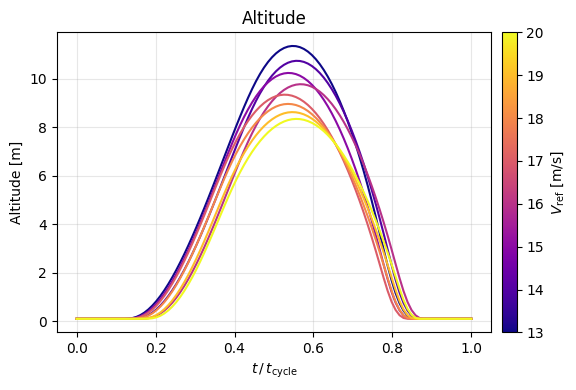

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))
for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        ax.plot(t_norm, opt.sol.value(opt.h), color=vref_color(V))
ax.set_ylabel('Altitude [m]')
ax.set_title('Altitude')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
add_vref_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('altitude.jpg', dpi=150, bbox_inches='tight')
plt.show()

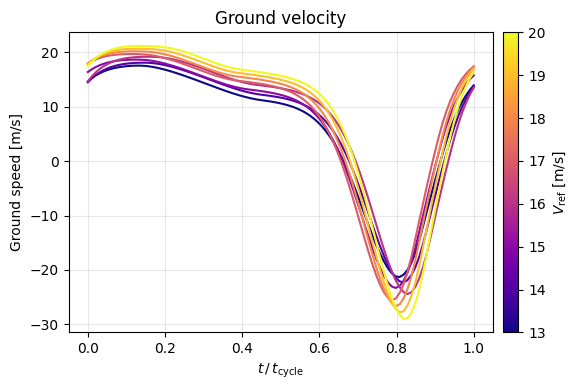

In [55]:
fig, ax = plt.subplots(figsize=(6, 4))
for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        ax.plot(t_norm, opt.sol.value(opt.v), color=vref_color(V))
ax.set_ylabel('Ground speed [m/s]')
ax.set_title('Ground velocity')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
add_vref_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('velocity.jpg', dpi=150, bbox_inches='tight')
plt.show()

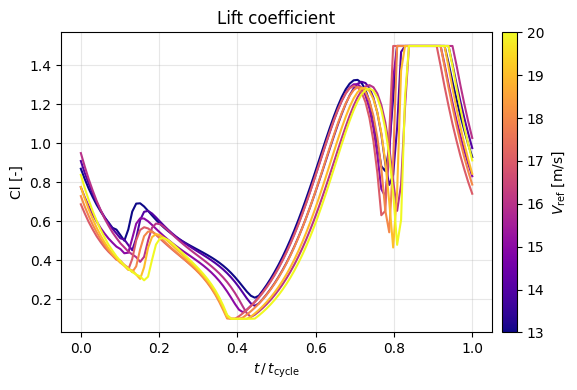

In [56]:
fig, ax = plt.subplots(figsize=(6, 4))
for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        ax.plot(t_norm, opt.sol.value(opt.cl), color=vref_color(V))
ax.set_ylabel('Cl [-]')
ax.set_title('Lift coefficient')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
add_vref_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cl.jpg', dpi=150, bbox_inches='tight')
plt.show()

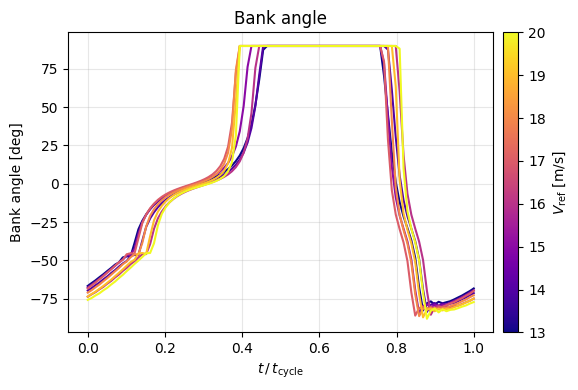

In [57]:
fig, ax = plt.subplots(figsize=(6, 4))
for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        ax.plot(t_norm, np.degrees(opt.sol.value(opt.mu)), color=vref_color(V))
ax.set_ylabel('Bank angle [deg]')
ax.set_title('Bank angle')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
add_vref_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mu.jpg', dpi=150, bbox_inches='tight')
plt.show()

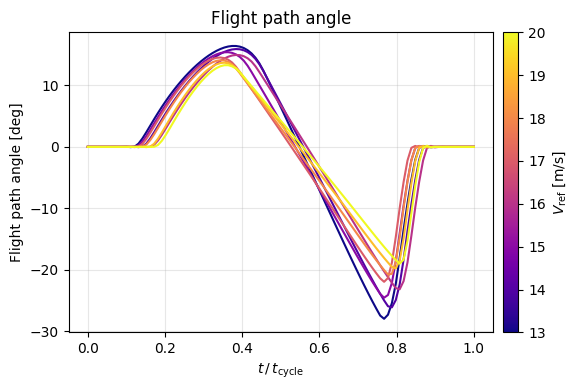

In [58]:
fig, ax = plt.subplots(figsize=(6, 4))
for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        ax.plot(t_norm, np.degrees(opt.sol.value(opt.gamma)), color=vref_color(V))
ax.set_ylabel('Flight path angle [deg]')
ax.set_title('Flight path angle')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
add_vref_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gamma.jpg', dpi=150, bbox_inches='tight')
plt.show()

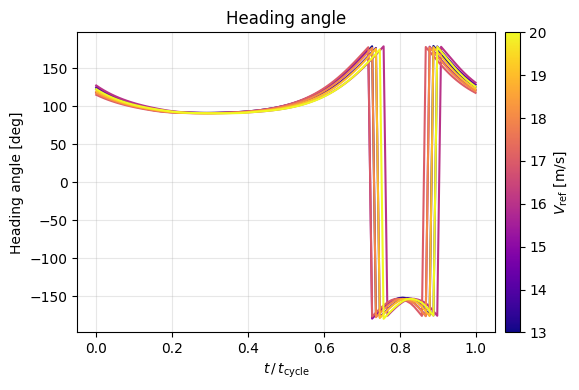

In [59]:
fig, ax = plt.subplots(figsize=(6, 4))
for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        ax.plot(t_norm, np.degrees(opt.sol.value(opt.xi)), color=vref_color(V))
ax.set_ylabel('Heading angle [deg]')
ax.set_title('Heading angle')
ax.set_xlabel(r'$t\,/\,t_{\mathrm{cycle}}$')
add_vref_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xi.jpg', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
import plotly.graph_objects as go

fig = go.Figure()
all_x, all_y, all_z = [], [], []

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        sol = opt.sol
        dt_val = sol.value(opt.dt)
        u_sol  = sol.value(opt.u)
        v_sol  = sol.value(opt.v)
        h_sol  = sol.value(opt.h)
        speed  = sol.value(opt.V_a)

        x_sol = np.zeros(N)
        y_sol = np.zeros(N)
        for i in range(1, N):
            x_sol[i] = x_sol[i-1] + 0.5 * (u_sol[i] + u_sol[i-1]) * dt_val
            y_sol[i] = y_sol[i-1] + 0.5 * (v_sol[i] + v_sol[i-1]) * dt_val

        all_x.append(x_sol); all_y.append(y_sol); all_z.append(h_sol)
        color_hex = vref_color(V)

        fig.add_trace(go.Scatter3d(
            x=x_sol, y=y_sol, z=h_sol,
            mode='lines',
            line=dict(color=color_hex, width=5),
            name=f'V_ref={V:.0f} m/s',
        ))
        fig.add_trace(go.Scatter3d(
            x=[x_sol[0]], y=[y_sol[0]], z=[h_sol[0]],
            mode='markers',
            marker=dict(size=6, color='green'),
            name='Start', showlegend=False,
        ))

all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)
all_z = np.concatenate(all_z)
span = max(all_x.max()-all_x.min(), all_y.max()-all_y.min(), all_z.max()-all_z.min())
cx = 0.5*(all_x.max()+all_x.min())
cy = 0.5*(all_y.max()+all_y.min())
cz = 0.5*(all_z.max()+all_z.min())

fig.update_layout(
    title='Dynamic Soaring Orbits — all V_ref values',
    scene=dict(
        xaxis=dict(title='x [m]', range=[cx-span/2, cx+span/2], autorange=False),
        yaxis=dict(title='y [m]', range=[cy-span/2, cy+span/2], autorange=False),
        zaxis=dict(title='h [m]', range=[0, cz+span/2], autorange=False),
        aspectmode='cube',
    ),
    width=800, height=700,
    margin=dict(l=0, r=80, t=40, b=0),
)
fig.show()

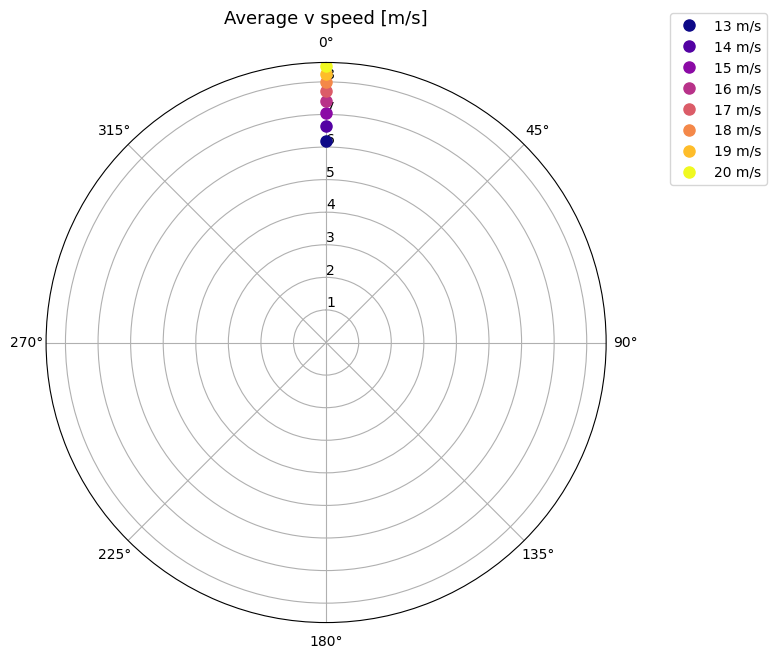

In [61]:
fig1, ax1 = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        ax1.plot(opt.theta, opt.sol.value(opt.v_avg),
                 'o', color=vref_color(V), ms=8, label=f'{V:.0f} m/s')

ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_title("Average v speed [m/s]", va="bottom", fontsize=13)
ax1.set_rlabel_position(0)
ax1.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

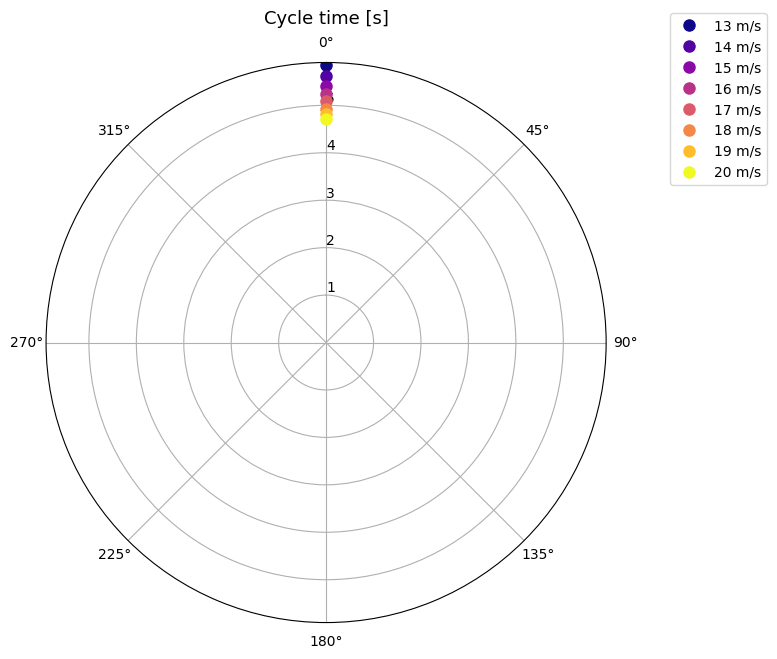

In [62]:
fig1, ax1 = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        ax1.plot(opt.theta, opt.sol.value(opt.T_cycle),
                 'o', color=vref_color(V), ms=8, label=f'{V:.0f} m/s')

ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_title(r"Cycle time [s]", va="bottom", fontsize=13)
ax1.set_rlabel_position(0)
ax1.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

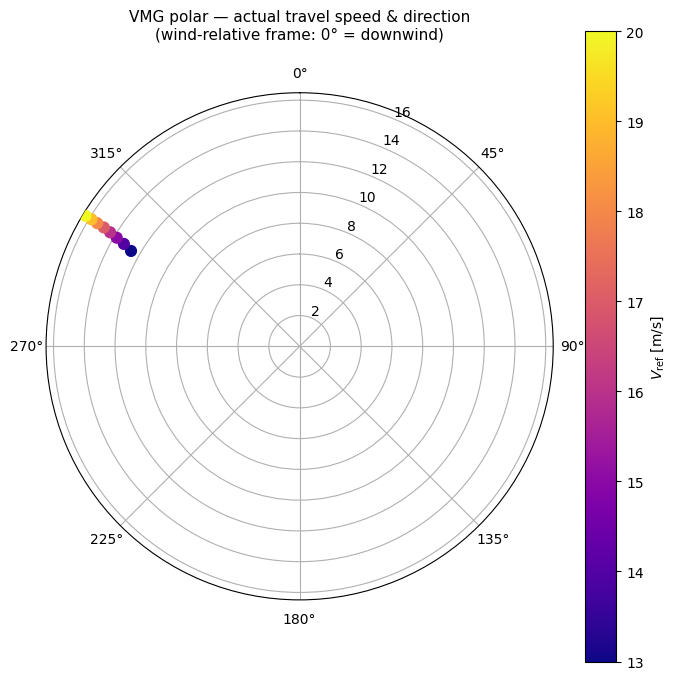

In [63]:
vmg_angles = []
vmg_speeds = []
vmg_vrefs  = []

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        sol       = opt.sol
        theta_val = float(opt.theta)
        u_mean    = float(np.mean(sol.value(opt.u)))
        v_mean    = float(np.mean(sol.value(opt.v)))

        v_downwind  = u_mean * np.sin(theta_val) + v_mean * np.cos(theta_val)
        u_crosswind = u_mean * np.cos(theta_val) - v_mean * np.sin(theta_val)

        angle = np.arctan2(u_crosswind, v_downwind) % (2 * np.pi)
        speed = np.sqrt(u_mean**2 + v_mean**2)

        vmg_angles.append(angle)
        vmg_speeds.append(speed)
        vmg_vrefs.append(V)

vmg_angles = np.array(vmg_angles)
vmg_speeds = np.array(vmg_speeds)
vmg_vrefs  = np.array(vmg_vrefs)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))
sc = ax.scatter(vmg_angles, vmg_speeds,
                c=vmg_vrefs, cmap='plasma',
                vmin=_Vs_arr.min(), vmax=_Vs_arr.max(),
                s=60, zorder=3)
plt.colorbar(sc, ax=ax, label=r'$V_{\rm ref}$ [m/s]')
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title("VMG polar — actual travel speed & direction\n"
             "(wind-relative frame: 0° = downwind)", fontsize=11, pad=20)
plt.tight_layout()
plt.savefig('vmg_polar.jpg', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
import plotly.graph_objects as go

g = 9.80665
fig_E = go.Figure()

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        sol       = opt.sol
        color_hex = vref_color(V)

        h_sol     = sol.value(opt.h)
        gamma_sol = sol.value(opt.gamma)
        xi_sol    = np.unwrap(sol.value(opt.xi))
        Va_sol    = sol.value(opt.V_a)

        E_sol = g * h_sol + 0.5 * Va_sol**2
        E_sol = (E_sol - E_sol.min()) / (E_sol.max() - E_sol.min())

        xi_loop    = np.append(xi_sol,    xi_sol[0])
        gamma_loop = np.append(gamma_sol, gamma_sol[0])
        E_loop     = np.append(E_sol,     E_sol[0])

        fig_E.add_trace(go.Scatter3d(
            x=np.degrees(xi_loop),
            y=np.degrees(gamma_loop),
            z=E_loop,
            mode='lines',
            line=dict(color=color_hex, width=3),
            name=f'V_ref={V:.0f} m/s',
            hovertemplate=(
                f'V_ref = {V:.0f} m/s<br>'
                'ξ: %{x:.1f}°<br>'
                'γ: %{y:.1f}°<br>'
                'E (norm): %{z:.2f}<extra></extra>'
            ),
        ))

# Dummy colorbar trace
fig_E.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='markers',
    marker=dict(
        color=list(_Vs_arr),
        colorscale='plasma',
        cmin=float(_Vs_arr.min()), cmax=float(_Vs_arr.max()),
        colorbar=dict(title='V_ref [m/s]', len=0.5, thickness=15, x=1.0),
        size=0,
    ),
    showlegend=False,
))

fig_E.update_layout(
    title=dict(
        text=f'State-space orbits (ξ, γ, E) — all V_ref values',
        x=0.5,
    ),
    scene=dict(
        xaxis_title='ξ — heading angle [°] (unwrapped)',
        yaxis_title='γ — flight path angle [°]',
        zaxis_title='E (normalised)',
        aspectmode='auto',
        camera=dict(eye=dict(x=1.6, y=1.6, z=0.8)),
    ),
    width=900, height=700,
    margin=dict(l=0, r=80, t=60, b=0),
)
fig_E.show()

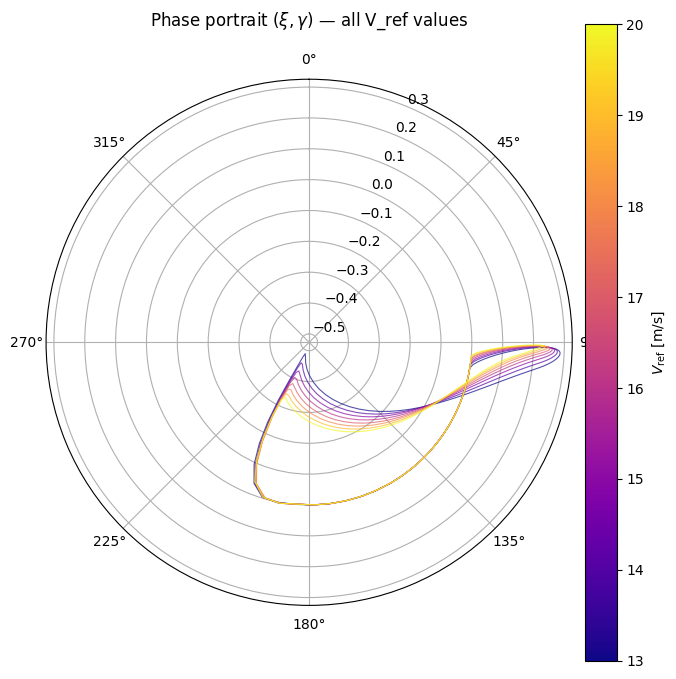

In [65]:
fig_polar, ax_polar = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        sol = opt.sol
        xi_sol    = np.unwrap(sol.value(opt.xi))
        gamma_sol = sol.value(opt.gamma)

        xi_loop    = np.append(xi_sol,    xi_sol[0])
        gamma_loop = np.append(gamma_sol, gamma_sol[0])

        ax_polar.plot(xi_loop, gamma_loop, color=vref_color(V), lw=0.8, alpha=0.7)

add_vref_colorbar(fig_polar, ax_polar)
ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)
ax_polar.set_title(r'Phase portrait $(ξ, γ)$ — all V_ref values', pad=20)
plt.tight_layout()
plt.show()

In [66]:
import plotly.graph_objects as go

g = 9.80665
fig_E = go.Figure()

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        sol       = opt.sol
        color_hex = vref_color(V)

        h_sol     = sol.value(opt.h)
        gamma_sol = sol.value(opt.gamma)
        xi_sol    = np.unwrap(sol.value(opt.xi))
        Va_sol    = sol.value(opt.V_a)

        # Wind-power proxy on the z-axis
        E_sol = V * (h_sol / 10)**0.143
        E_sol = (E_sol - E_sol.min()) / (E_sol.max() - E_sol.min())

        xi_loop    = np.append(xi_sol,    xi_sol[0])
        gamma_loop = np.append(gamma_sol, gamma_sol[0])
        E_loop     = np.append(E_sol,     E_sol[0])

        fig_E.add_trace(go.Scatter3d(
            x=np.degrees(xi_loop),
            y=np.degrees(gamma_loop),
            z=E_loop,
            mode='lines',
            line=dict(color=color_hex, width=3),
            name=f'V_ref={V:.0f} m/s',
            hovertemplate=(
                f'V_ref = {V:.0f} m/s<br>'
                'ξ: %{x:.1f}°<br>'
                'γ: %{y:.1f}°<br>'
                'wind power (norm): %{z:.2f}<extra></extra>'
            ),
        ))

fig_E.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='markers',
    marker=dict(
        color=list(_Vs_arr),
        colorscale='plasma',
        cmin=float(_Vs_arr.min()), cmax=float(_Vs_arr.max()),
        colorbar=dict(title='V_ref [m/s]', len=0.5, thickness=15, x=1.0),
        size=0,
    ),
    showlegend=False,
))

fig_E.update_layout(
    title=dict(
        text='State-space orbits (ξ, γ, wind-power) — all V_ref values',
        x=0.5,
    ),
    scene=dict(
        xaxis_title='ξ — heading angle [°] (unwrapped)',
        yaxis_title='γ — flight path angle [°]',
        zaxis_title='Wind power (normalised)',
        aspectmode='auto',
        camera=dict(eye=dict(x=1.6, y=1.6, z=0.8)),
    ),
    width=900, height=700,
    margin=dict(l=0, r=80, t=60, b=0),
)
fig_E.show()

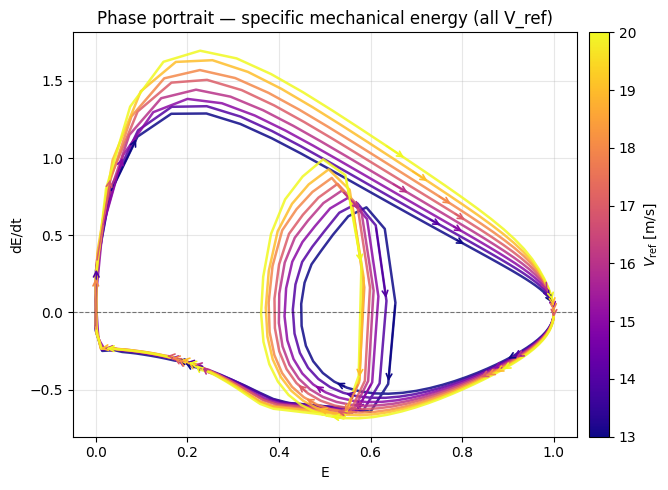

In [69]:
# Overlaid phase portraits: dE/dt vs E — one orbit per V_ref
g = 9.80665

fig, ax = plt.subplots(figsize=(7, 5))

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        sol    = opt.sol
        h_sol  = sol.value(opt.h)
        Va_sol = sol.value(opt.V_a)
        dt_val = float(sol.value(opt.dt))

        E_sol  = g * h_sol + 0.5 * Va_sol**2
        E_sol = (E_sol - E_sol.min()) / (E_sol.max() - E_sol.min())
        dEdt   = np.gradient(E_sol, dt_val)   # central differences

        # Close the loop
        E_phase    = np.append(E_sol, E_sol[0])
        dEdt_phase = np.append(dEdt,  dEdt[0])

        color = vref_color(V)
        ax.plot(E_phase, dEdt_phase, color=color, lw=1.8, alpha=0.85)

        # Direction arrows
        for i in np.linspace(0, N - 1, 8, dtype=int):
            j = (i + 1) % N
            ax.annotate('',
                        xy=(E_sol[j], dEdt[j]),
                        xytext=(E_sol[i], dEdt[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
add_vref_colorbar(fig, ax)
ax.set_xlabel('E')
ax.set_ylabel('dE/dt')
ax.set_title('Phase portrait — specific mechanical energy (all V_ref)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

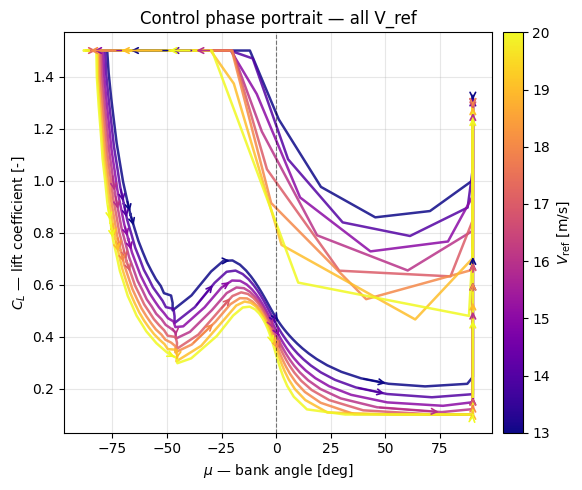

In [70]:
# Control phase portrait: bank angle (mu) vs lift coefficient (cl) — all V_ref
fig, ax = plt.subplots(figsize=(6, 5))

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        sol    = opt.sol
        mu_sol = sol.value(opt.mu)
        cl_sol = sol.value(opt.cl)

        # Close the loop
        mu_loop = np.append(mu_sol, mu_sol[0])
        cl_loop = np.append(cl_sol, cl_sol[0])

        color = vref_color(V)
        ax.plot(np.degrees(mu_loop), cl_loop, color=color, lw=1.8, alpha=0.85)

        # Direction arrows
        for i in np.linspace(0, N - 1, 8, dtype=int):
            j = (i + 1) % N
            ax.annotate('',
                        xy=(np.degrees(mu_sol[j]), cl_sol[j]),
                        xytext=(np.degrees(mu_sol[i]), cl_sol[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

add_vref_colorbar(fig, ax)
ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel(r'$\mu$ — bank angle [deg]')
ax.set_ylabel(r'$C_L$ — lift coefficient [-]')
ax.set_title('Control phase portrait — all V_ref')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

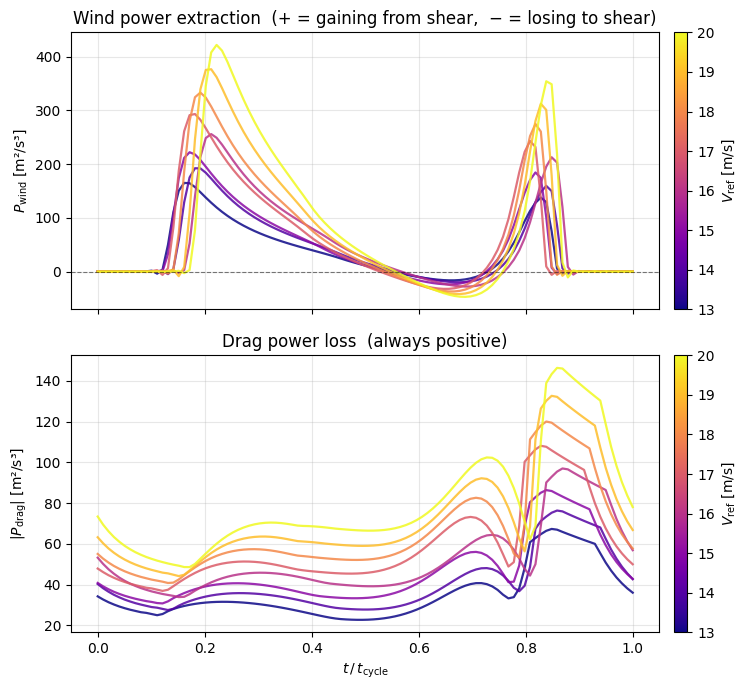

In [71]:
# Energy power budget over one cycle: wind extraction vs drag loss
#
# From differentiating E = g·h + ½·Vₐ² and substituting the equations of motion:
#   dE/dt = P_wind + P_drag
#
# Lift contributes zero (perpendicular to Vₐ).
# Gravity terms cancel exactly between the potential and kinetic sides.
#
# P_drag = −D·Vₐ/m                                 (always negative)
# P_wind = (uₐ·sinθ + vₐ·cosθ) · V_ref·p·(h/h_ref)^(p−1)·(−ẇ)/h_ref
#   where uₐ = u + Vwx, vₐ = v + Vwy  (airspeed components)
#   and (uₐ·sinθ + vₐ·cosθ) is the airspeed projected onto the wind direction

_rho   = 1.225
_p_exp = 0.143
_h_ref = 10.0

fig, (ax_wind, ax_drag) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

for result in results:
    V = result['V_ref']
    for opt in result['solutions']:
        sol   = opt.sol
        theta = float(opt.theta)
        m, S  = opt.bird.m, opt.bird.S
        cd0, k_ind = opt.bird.cd_0, opt.bird.k

        h_sol  = sol.value(opt.h)
        u_sol  = sol.value(opt.u)
        v_sol  = sol.value(opt.v)
        w_sol  = sol.value(opt.w)
        Va_sol = sol.value(opt.V_a)
        cl_sol = sol.value(opt.cl)

        # --- drag power ---
        cd_sol = cd0 + k_ind * cl_sol**2
        D_sol  = 0.5 * _rho * Va_sol**2 * S * cd_sol
        P_drag = -D_sol * Va_sol / m          # always ≤ 0

        # --- wind shear power ---
        # rate of change of wind speed at the bird's location as it moves vertically
        wind_gradient = V * _p_exp * (h_sol / _h_ref)**(_p_exp - 1) / _h_ref * (-w_sol)
        ua   = u_sol + np.sin(theta) * V * (h_sol / _h_ref)**_p_exp
        va_c = v_sol + np.cos(theta) * V * (h_sol / _h_ref)**_p_exp
        # airspeed projected onto wind direction × wind gradient
        P_wind = (ua * np.sin(theta) + va_c * np.cos(theta)) * wind_gradient

        color = vref_color(V)
        ax_wind.plot(t_norm, P_wind,  color=color, lw=1.6, alpha=0.85)
        ax_drag.plot(t_norm, -P_drag, color=color, lw=1.6, alpha=0.85)  # plot as positive loss

ax_wind.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax_wind.set_ylabel(r'$P_{\rm wind}$ [m²/s³]')
ax_wind.set_title('Wind power extraction  (+ = gaining from shear,  − = losing to shear)')
ax_wind.grid(True, alpha=0.3)
add_vref_colorbar(fig, ax_wind)

ax_drag.set_ylabel(r'$|P_{\rm drag}|$ [m²/s³]')
ax_drag.set_title('Drag power loss  (always positive)')
ax_drag.set_xlabel(r'$t\,/\,t_{\rm cycle}$')
ax_drag.grid(True, alpha=0.3)
add_vref_colorbar(fig, ax_drag)

plt.tight_layout()
plt.show()